# Notebook 07: Notable Events, Weekly Patterns & the Uri Retrospective

**One Sensor, One Year — Edition 2: Texas Grid**

The events notebook. What are the record days of 2025? How does Texas look on a weekday vs a weekend? And four years later, how does Feb 2025 compare to Feb 2021 — the week Winter Storm Uri broke the grid?

**Inputs:**
- `../data/processed/texas_2025_derived.csv` — daily with emissions (from N03)
- `../data/processed/texas_2025_hourly.csv` — 8,760 hourly rows (from N01)
- `../data/raw/previous_years/IntGenbyFuel2021.xlsx` — unpacked in N05

**Outputs:**
- `../data/processed/texas_2025_events.json` — compact list of event records for web / essay
- `../data/processed/weekday_weekend_profile.png` — static weekly pattern chart
- `../data/processed/uri_vs_2025.png` — static Feb 2021 vs Feb 2025 comparison
- `../web/events.html` — interactive event browser (scatter of days, hover for record cards)

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
RAW = Path('../data/raw')
WEB = Path('../web')
WEB.mkdir(parents=True, exist_ok=True)

daily = pd.read_csv(PROCESSED / 'texas_2025_derived.csv', parse_dates=['Date'], index_col='Date')
hourly = pd.read_csv(PROCESSED / 'texas_2025_hourly.csv', parse_dates=['timestamp'], index_col='timestamp')
print(f'Daily: {len(daily)} rows')
print(f'Hourly: {len(hourly)} rows')

fuel_colors = {
    'coal':      '#D4890E',
    'gas':       '#E8A94A',
    'gas_cc':    '#F0C078',
    'gas_total': '#F0C078',
    'nuclear':   '#2A9D8F',
    'hydro':     '#264653',
    'wind':      '#72B352',
    'solar':     '#F4C430',
    'biomass':   '#8B6F47',
    'other':     '#9B72CF',
}
GEN_COLS = ['coal', 'gas_total', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other']
daily['total_gen'] = daily[GEN_COLS].sum(axis=1)

Daily: 365 rows
Hourly: 8760 rows


## 1. Record hunt — the headline days of 2025

For each record category, pick the extreme day and record its stat plus a brief description of what the mix looked like.

In [2]:
events = []

def record(date, kind, headline, description):
    events.append({
        'date': pd.Timestamp(date).strftime('%Y-%m-%d'),
        'day_of_year': int(pd.Timestamp(date).dayofyear),
        'weekday': pd.Timestamp(date).strftime('%A'),
        'kind': kind,
        'headline': headline,
        'description': description,
    })

# Highest total generation
d = daily['total_gen'].idxmax()
record(d, 'peak_generation',
       f'{daily.loc[d, "total_gen"]/1e3:,.0f} GWh',
       f'Peak generation day — demand maxed, gas-CC at {daily.loc[d, "gas_cc"]/1e3:,.0f} GWh, wind at {daily.loc[d, "wind"]/1e3:,.0f} GWh')

# Lowest total generation
d = daily['total_gen'].idxmin()
record(d, 'lowest_generation',
       f'{daily.loc[d, "total_gen"]/1e3:,.0f} GWh',
       f'Lowest generation day — mild weather, gas-CC at {daily.loc[d, "gas_cc"]/1e3:,.0f} GWh')

# Highest wind day
d = daily['wind'].idxmax()
w_pct = daily.loc[d, 'wind'] / daily.loc[d, 'total_gen'] * 100
record(d, 'wind_record',
       f'{daily.loc[d, "wind"]/1e3:,.0f} GWh ({w_pct:.1f}% of mix)',
       f'Wind record — {daily.loc[d, "wind"]/1e3:,.0f} GWh from wind ({w_pct:.1f}% of total generation)')

# Highest solar day
d = daily['solar'].idxmax()
s_pct = daily.loc[d, 'solar'] / daily.loc[d, 'total_gen'] * 100
record(d, 'solar_record',
       f'{daily.loc[d, "solar"]/1e3:,.0f} GWh ({s_pct:.1f}%)',
       f'Solar record — {daily.loc[d, "solar"]/1e3:,.0f} GWh from solar ({s_pct:.1f}% of total generation)')

# Highest gas day
d = daily['gas_total'].idxmax()
g_pct = daily.loc[d, 'gas_total'] / daily.loc[d, 'total_gen'] * 100
record(d, 'gas_peak',
       f'{daily.loc[d, "gas_total"]/1e3:,.0f} GWh ({g_pct:.1f}%)',
       f'Gas peak day — gas covered {g_pct:.1f}% of generation')

# Cleanest day (lowest emissions intensity)
d = daily['intensity'].idxmin()
clean_pct = (daily.loc[d, ['nuclear','hydro','wind','solar']].sum()
             / daily.loc[d, 'total_gen'] * 100)
record(d, 'cleanest_day',
       f'{daily.loc[d, "intensity"]:.3f} tCO2/MWh',
       f'Cleanest day of 2025 — {clean_pct:.1f}% clean mix, intensity {daily.loc[d, "intensity"]:.3f} tCO2/MWh')

# Dirtiest day
d = daily['intensity'].idxmax()
record(d, 'dirtiest_day',
       f'{daily.loc[d, "intensity"]:.3f} tCO2/MWh',
       f'Dirtiest day of 2025 — intensity {daily.loc[d, "intensity"]:.3f} tCO2/MWh, coal at {daily.loc[d, "coal"]/1e3:,.0f} GWh')

# Highest renewable share (wind+solar+nuclear+hydro)
clean_share = (daily[['nuclear','hydro','wind','solar']].sum(axis=1) / daily['total_gen'])
d = clean_share.idxmax()
record(d, 'greenest_mix',
       f'{clean_share.loc[d]*100:.1f}% clean',
       f'Greenest mix day — {clean_share.loc[d]*100:.1f}% of generation from nuclear + hydro + wind + solar')

print(f'{len(events)} event records captured:')
for e in events:
    print(f'  {e["date"]} ({e["weekday"][:3]}) — {e["kind"]}: {e["headline"]}')

8 event records captured:
  2025-02-19 (Wed) — peak_generation: 1,750 GWh
  2025-03-16 (Sun) — lowest_generation: 1,048 GWh
  2025-03-06 (Thu) — wind_record: 611 GWh (53.4% of mix)
  2025-07-29 (Tue) — solar_record: 305 GWh (18.4%)
  2025-02-21 (Fri) — gas_peak: 995 GWh (60.5%)
  2025-03-06 (Thu) — cleanest_day: 0.148 tCO2/MWh
  2025-01-28 (Tue) — dirtiest_day: 0.433 tCO2/MWh
  2025-03-06 (Thu) — greenest_mix: 73.6% clean


## 2. Cleanest and dirtiest hours of 2025

With hourly data we can zoom in past the daily level. Apply the same emission factors to the hourly generation and find the single hour with the lowest and highest intensity.

In [3]:
# Same factors as N03
EF = {'coal': 0.95, 'gas': 0.55, 'gas_cc': 0.37, 'biomass': 0.0,
      'other': 0.65, 'nuclear': 0.0, 'hydro': 0.0, 'wind': 0.0, 'solar': 0.0}

h = hourly.copy()
for fuel, factor in EF.items():
    h[f'co2_{fuel}'] = h[fuel] * factor
emitting = [f for f in EF if EF[f] > 0]
h['co2_total'] = h[[f'co2_{f}' for f in emitting]].sum(axis=1)
# total gen for intensity denominator
GEN = ['coal', 'gas', 'gas_cc', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other']
h['gen_total'] = h[GEN].sum(axis=1)
h['intensity'] = h['co2_total'] / h['gen_total'].replace(0, np.nan)

# Drop the impossible-zero row that DST spring-forward leaves behind
h_valid = h[h['gen_total'] > 10000].copy()  # at least 10 GWh/hr

cleanest = h_valid['intensity'].idxmin()
dirtiest = h_valid['intensity'].idxmax()

def describe_hour(ts, kind, headline, desc):
    row = h_valid.loc[ts]
    record(ts.normalize(), kind, headline, desc)
    print(f'{kind.upper()}: {ts}')
    print(f'  Intensity: {row["intensity"]:.3f} tCO2/MWh')
    print(f'  Total gen: {row["gen_total"]/1e3:.1f} GWh/h')
    top3 = row[GEN].sort_values(ascending=False).head(3)
    for fuel in top3.index:
        pct = row[fuel] / row['gen_total'] * 100
        print(f'  {fuel:8s}: {row[fuel]/1e3:6.1f} GWh/h ({pct:5.1f}%)')
    print()

describe_hour(
    cleanest, 'cleanest_hour',
    f'{h_valid.loc[cleanest, "intensity"]:.3f} tCO2/MWh',
    f'Cleanest hour of 2025 — {h_valid.loc[cleanest, "wind"]/1e3:.1f} GWh wind + {h_valid.loc[cleanest, "solar"]/1e3:.1f} GWh solar'
)
describe_hour(
    dirtiest, 'dirtiest_hour',
    f'{h_valid.loc[dirtiest, "intensity"]:.3f} tCO2/MWh',
    f'Dirtiest hour of 2025 — coal + simple-cycle gas dominated, minimal wind'
)

CLEANEST_HOUR: 2025-03-06 16:00:00
  Intensity: 0.082 tCO2/MWh
  Total gen: 47.0 GWh/h
  wind    :   25.3 GWh/h ( 53.8%)
  solar   :   10.0 GWh/h ( 21.4%)
  nuclear :    5.1 GWh/h ( 10.8%)

DIRTIEST_HOUR: 2025-09-25 20:00:00
  Intensity: 0.495 tCO2/MWh
  Total gen: 65.7 GWh/h
  gas_cc  :   29.7 GWh/h ( 45.2%)
  gas     :   13.3 GWh/h ( 20.3%)
  coal    :   10.5 GWh/h ( 15.9%)



## 3. Weekday vs weekend signature

Commercial and industrial load drops on weekends. Is the effect visible in the 2025 data?

In [4]:
hourly['dayname'] = hourly.index.day_name()
hourly['is_weekend'] = hourly.index.dayofweek >= 5
hourly['total_gen'] = hourly[GEN_COLS].sum(axis=1)

# Average hourly profile for weekday vs weekend
PROFILE_COLS = GEN_COLS + ['total_gen']
we_profile = hourly.groupby(['is_weekend', hourly.index.hour])[PROFILE_COLS].mean() / 1e3
wd = we_profile.xs(False)
we = we_profile.xs(True)

print('Average daily totals:')
print(f'  Weekday mean: {wd["total_gen"].sum():,.0f} GWh/day')
print(f'  Weekend mean: {we["total_gen"].sum():,.0f} GWh/day')
print(f'  Weekend dip:  {(1 - we["total_gen"].sum() / wd["total_gen"].sum()) * 100:+.1f}%')
print()
print('Mean hourly generation by hour:')
for hour in range(24):
    wdv = wd.loc[hour, 'total_gen']
    wev = we.loc[hour, 'total_gen']
    print(f'  Hour {hour:02d}: weekday {wdv:5.1f} | weekend {wev:5.1f} | diff {wdv-wev:+5.1f} GWh/h')

Average daily totals:
  Weekday mean: 1,371 GWh/day
  Weekend mean: 1,316 GWh/day
  Weekend dip:  +4.0%

Mean hourly generation by hour:
  Hour 00: weekday  54.0 | weekend  53.4 | diff  +0.6 GWh/h
  Hour 01: weekday  51.7 | weekend  51.2 | diff  +0.5 GWh/h
  Hour 02: weekday  50.1 | weekend  49.5 | diff  +0.6 GWh/h
  Hour 03: weekday  49.0 | weekend  47.8 | diff  +1.2 GWh/h
  Hour 04: weekday  48.3 | weekend  47.3 | diff  +1.0 GWh/h
  Hour 05: weekday  48.3 | weekend  46.7 | diff  +1.5 GWh/h
  Hour 06: weekday  49.4 | weekend  46.7 | diff  +2.7 GWh/h
  Hour 07: weekday  51.5 | weekend  47.2 | diff  +4.4 GWh/h
  Hour 08: weekday  52.9 | weekend  48.2 | diff  +4.6 GWh/h
  Hour 09: weekday  55.1 | weekend  51.5 | diff  +3.7 GWh/h
  Hour 10: weekday  57.6 | weekend  54.7 | diff  +2.9 GWh/h
  Hour 11: weekday  59.0 | weekend  56.3 | diff  +2.6 GWh/h
  Hour 12: weekday  60.0 | weekend  57.6 | diff  +2.4 GWh/h
  Hour 13: weekday  61.3 | weekend  58.8 | diff  +2.4 GWh/h
  Hour 14: weekday  62.

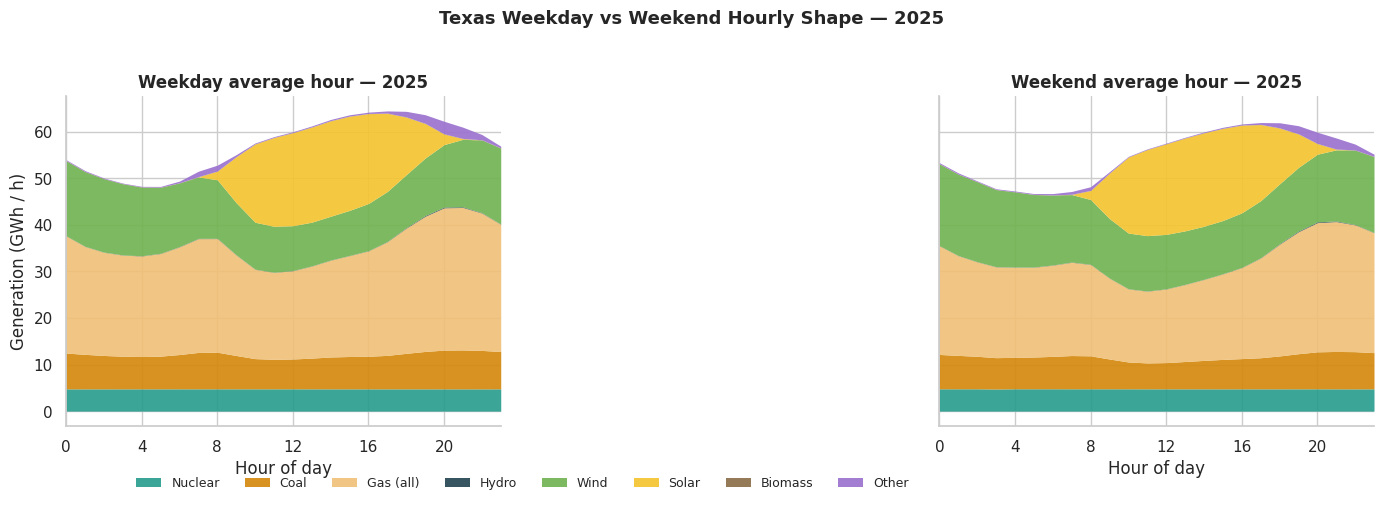

Saved ../data/processed/weekday_weekend_profile.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

STACK_ORDER = ['nuclear', 'coal', 'gas_total', 'hydro', 'wind', 'solar', 'biomass', 'other']
stack_labels_simple = {
    'nuclear': 'Nuclear', 'coal': 'Coal', 'gas_total': 'Gas (all)',
    'hydro': 'Hydro', 'wind': 'Wind', 'solar': 'Solar',
    'biomass': 'Biomass', 'other': 'Other',
}

for ax, (title, prof) in zip(axes, [('Weekday', wd), ('Weekend', we)]):
    bottom = np.zeros(24)
    for fuel in STACK_ORDER:
        vals = prof[fuel].values
        ax.fill_between(range(24), bottom, bottom + vals,
                        color=fuel_colors.get(fuel, '#888'),
                        label=stack_labels_simple.get(fuel, fuel),
                        alpha=0.92, linewidth=0)
        bottom += vals
    ax.set_title(f'{title} average hour — 2025', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hour of day')
    ax.set_xticks(range(0, 25, 4))
    ax.set_xlim(0, 23)

axes[0].set_ylabel('Generation (GWh / h)')
axes[0].legend(loc='upper center', bbox_to_anchor=(1.05, -0.12),
               ncol=8, frameon=False, fontsize=9)
plt.suptitle('Texas Weekday vs Weekend Hourly Shape — 2025',
             fontsize=13, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig(PROCESSED / 'weekday_weekend_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {PROCESSED / "weekday_weekend_profile.png"}')

## 4. Uri retrospective — February 2021 vs February 2025

In February 2021, Winter Storm Uri froze Texas. Gas wellheads froze, coal piles froze, wind turbines iced over, and one nuclear reactor tripped offline. ERCOT shed load for days and 200+ people died.

Four years later, Texas has added ~40 GW of new capacity — much of it winterized solar and batteries. How does Feb 2025 compare?

We load Feb 2021 daily totals directly from the historical XLSX.

In [6]:
uri_file = RAW / 'previous_years' / 'IntGenbyFuel2021.xlsx'
feb2021_raw = pd.read_excel(uri_file, sheet_name='Feb')
feb2021_raw['Date'] = pd.to_datetime(feb2021_raw['Date'])

# Pivot to daily-by-fuel
feb2021 = feb2021_raw.pivot_table(index='Date', columns='Fuel',
                                  values='Total', aggfunc='sum').fillna(0)
# Normalize fuel column names to match our schema
feb2021 = feb2021.rename(columns={
    'Coal': 'coal', 'Gas': 'gas', 'Gas-CC': 'gas_cc',
    'Nuclear': 'nuclear', 'Hydro': 'hydro',
    'Wind': 'wind', 'Solar': 'solar',
    'Biomass': 'biomass', 'Other': 'other',
})
feb2021['gas_total'] = feb2021.get('gas', 0) + feb2021.get('gas_cc', 0)
feb2021['total_gen'] = feb2021[[c for c in GEN_COLS if c in feb2021.columns]].sum(axis=1)

feb2025 = daily.loc['2025-02-01':'2025-02-28'].copy()

print('Feb 2021 (Uri week, daily totals in GWh):')
print(feb2021.loc['2021-02-13':'2021-02-21', ['coal','gas_total','nuclear','wind','solar','total_gen']]
      .div(1e3).round(0).to_string())
print()
print(f'Feb 2025 total: {feb2025["total_gen"].sum()/1e6:.1f} TWh')
print(f'Feb 2021 total: {feb2021["total_gen"].sum()/1e6:.1f} TWh')
print(f'Feb 2021 minimum day: {feb2021["total_gen"].idxmin().date()} '
      f'at {feb2021["total_gen"].min()/1e3:,.0f} GWh')
print(f'Feb 2025 minimum day: {feb2025["total_gen"].idxmin().date()} '
      f'at {feb2025["total_gen"].min()/1e3:,.0f} GWh')

Feb 2021 (Uri week, daily totals in GWh):
Fuel         coal  gas_total  nuclear   wind  solar  total_gen
Date                                                          
2021-02-13  259.0      900.0    123.0   98.0    7.0     1393.0
2021-02-14  262.0      910.0    123.0  174.0    7.0     1482.0
2021-02-15  204.0      761.0     97.0   73.0   21.0     1162.0
2021-02-16  175.0      695.0     89.0   90.0   15.0     1068.0
2021-02-17  175.0      725.0     90.0   62.0   24.0     1079.0
2021-02-18  196.0      763.0    111.0  141.0   18.0     1235.0
2021-02-19  212.0      642.0    123.0  151.0   33.0     1164.0
2021-02-20  176.0      432.0    123.0  259.0   22.0     1014.0
2021-02-21  124.0      296.0    123.0  278.0   12.0      834.0

Feb 2025 total: 35.1 TWh
Feb 2021 total: 28.9 TWh
Feb 2021 minimum day: 2021-02-24 at 825 GWh
Feb 2025 minimum day: 2025-02-02 at 1,084 GWh


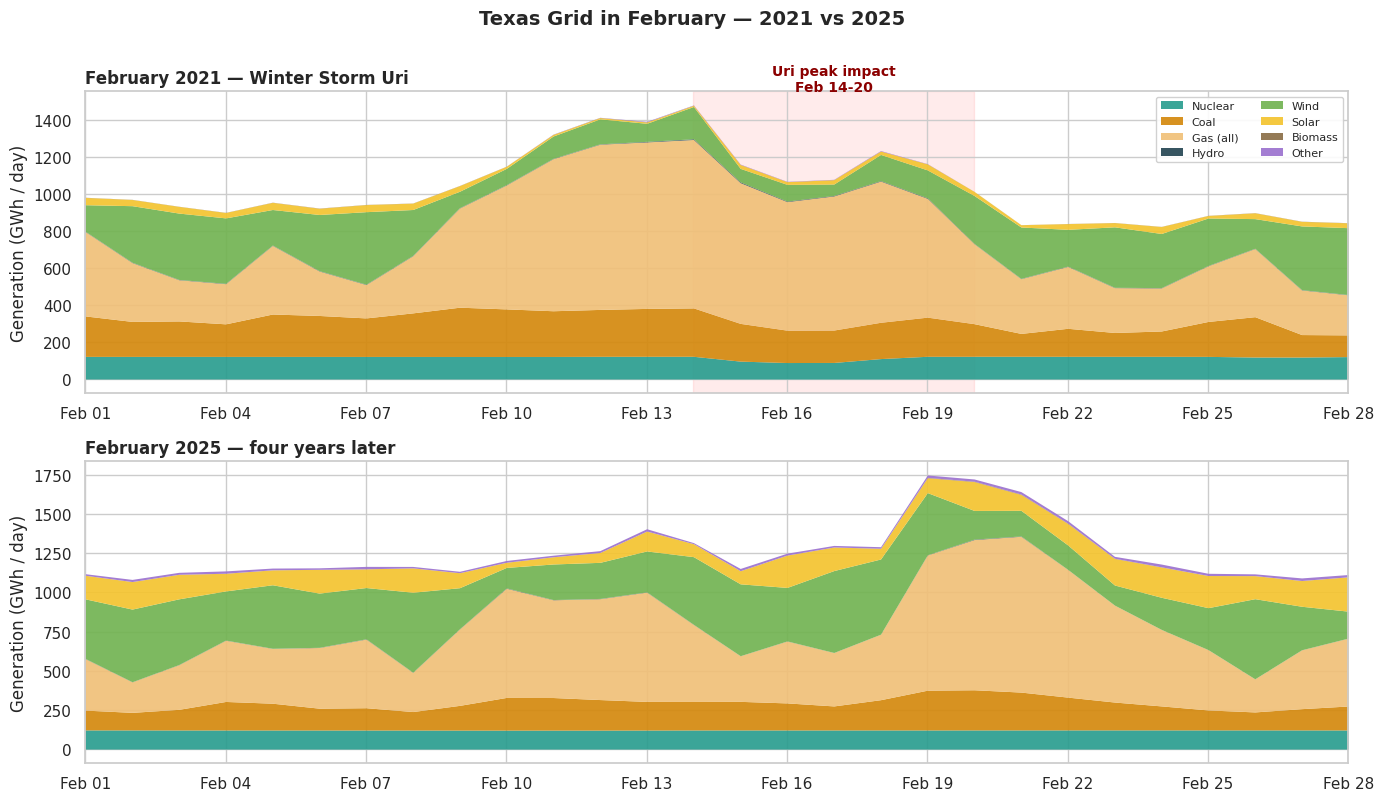

Saved ../data/processed/uri_vs_2025.png


In [7]:
# Two-panel comparison chart
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

URI_WINDOW_START = pd.Timestamp('2021-02-14')
URI_WINDOW_END = pd.Timestamp('2021-02-20')

for ax, (title, df, year) in zip(
    axes,
    [('February 2021 — Winter Storm Uri', feb2021, 2021),
     ('February 2025 — four years later', feb2025, 2025)],
):
    bottom = np.zeros(len(df))
    for fuel in STACK_ORDER:
        if fuel not in df.columns:
            continue
        vals = df[fuel].values / 1e3
        ax.fill_between(df.index, bottom, bottom + vals,
                        color=fuel_colors.get(fuel, '#888'),
                        label=stack_labels_simple.get(fuel, fuel),
                        alpha=0.92, linewidth=0)
        bottom += vals
    ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Generation (GWh / day)')
    ax.set_xlim(df.index.min(), df.index.max())
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=0)

    if year == 2021:
        ax.axvspan(URI_WINDOW_START, URI_WINDOW_END,
                   color='red', alpha=0.08, zorder=0)
        ax.annotate('Uri peak impact\nFeb 14-20',
                    xy=(URI_WINDOW_START + (URI_WINDOW_END - URI_WINDOW_START)/2, bottom.max()*1.05),
                    ha='center', fontsize=10, color='#8B0000', fontweight='bold')

axes[0].legend(loc='upper right', ncol=2, fontsize=8, framealpha=0.9)
plt.suptitle('Texas Grid in February — 2021 vs 2025',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(PROCESSED / 'uri_vs_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {PROCESSED / "uri_vs_2025.png"}')

# Register Uri as an event
uri_min_day = feb2021['total_gen'].idxmin()
record(uri_min_day, 'uri_memorial',
       f'{feb2021["total_gen"].min()/1e3:,.0f} GWh',
       f'Historical reference — Winter Storm Uri trough: on this day in 2021 the ERCOT grid delivered {feb2021["total_gen"].min()/1e3:,.0f} GWh, its lowest daily output of that winter, versus Feb 2025 trough of {feb2025["total_gen"].min()/1e3:,.0f} GWh.')

## 5. Interactive event browser — every day of 2025 as a point

Each day plotted by clean-share (y) vs day-of-year (x), sized by total generation, colored by month, hover to read the intensity.

In [8]:
daily_plot = daily.copy()
daily_plot['clean_share'] = (daily_plot[['nuclear','hydro','wind','solar']].sum(axis=1)
                             / daily_plot['total_gen']) * 100
daily_plot['doy'] = daily_plot.index.dayofyear
daily_plot['month'] = daily_plot.index.month
daily_plot['month_name'] = daily_plot.index.strftime('%b')

# Mark event days
event_dates = {pd.Timestamp(e['date']) for e in events if pd.Timestamp(e['date']).year == 2025}
daily_plot['is_event'] = daily_plot.index.isin(event_dates)

fig = go.Figure()

for month in range(1, 13):
    sub = daily_plot[daily_plot['month'] == month]
    fig.add_trace(go.Scatter(
        x=sub['doy'], y=sub['clean_share'],
        mode='markers',
        marker=dict(
            size=sub['total_gen'] / 1e5,
            sizemode='area',
            color=month, cmin=1, cmax=12, colorscale='Turbo',
            line=dict(width=sub['is_event'].map({True: 2, False: 0}),
                      color='#000'),
            showscale=(month == 1),
            colorbar=dict(title='Month', tickvals=list(range(1, 13)),
                          ticktext=['Jan','Feb','Mar','Apr','May','Jun',
                                    'Jul','Aug','Sep','Oct','Nov','Dec']) if month == 1 else None,
        ),
        name=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][month-1],
        text=[idx.strftime('%b %d, %a') for idx in sub.index],
        customdata=np.stack([
            sub['total_gen'].values / 1e3,
            sub['intensity'].values,
            sub['clean_share'].values,
        ], axis=-1),
        hovertemplate=(
            '<b>%{text}</b><br>' +
            'Clean share: %{customdata[2]:.1f}%<br>' +
            'Total gen:   %{customdata[0]:,.0f} GWh<br>' +
            'Intensity:   %{customdata[1]:.3f} tCO2/MWh<extra></extra>'
        ),
        showlegend=False,
    ))

fig.update_layout(
    title={
        'text': 'Texas 2025 — Every Day, by Clean Share and Generation<br>' +
                '<sub>Bubble size = total daily generation; hover for each day\'s stats</sub>',
        'x': 0.02, 'xanchor': 'left',
    },
    xaxis=dict(title='Day of year', dtick=30),
    yaxis=dict(title='Clean share (% of total)', range=[0, max(80, daily_plot['clean_share'].max()+5)]),
    plot_bgcolor='#FAFAF5', paper_bgcolor='#FAFAF5',
    height=560, width=1000,
    margin=dict(l=60, r=30, t=90, b=60),
)

fig.write_html(WEB / 'events.html', include_plotlyjs='cdn', full_html=True)
print(f'Saved {WEB / "events.html"}')
fig.show()

Saved ../web/events.html


## 6. Save the events JSON

Compact list for the essay / web captions / poster labels.

In [9]:
events_out = {
    'grid': 'ERCOT',
    'year': 2025,
    'generated': pd.Timestamp.utcnow().isoformat(),
    'records': events,
}

out_path = PROCESSED / 'texas_2025_events.json'
with open(out_path, 'w') as f:
    json.dump(events_out, f, indent=2, default=str)

print(f'Saved {out_path} ({len(events)} event records)')
print()
print(json.dumps(events_out, indent=2, default=str)[:1500] + '...')

Saved ../data/processed/texas_2025_events.json (11 event records)

{
  "grid": "ERCOT",
  "year": 2025,
  "generated": "2026-04-12T22:12:47.148267+00:00",
  "records": [
    {
      "date": "2025-02-19",
      "day_of_year": 50,
      "weekday": "Wednesday",
      "kind": "peak_generation",
      "headline": "1,750 GWh",
      "description": "Peak generation day \u2014 demand maxed, gas-CC at 608 GWh, wind at 397 GWh"
    },
    {
      "date": "2025-03-16",
      "day_of_year": 75,
      "weekday": "Sunday",
      "kind": "lowest_generation",
      "headline": "1,048 GWh",
      "description": "Lowest generation day \u2014 mild weather, gas-CC at 270 GWh"
    },
    {
      "date": "2025-03-06",
      "day_of_year": 65,
      "weekday": "Thursday",
      "kind": "wind_record",
      "headline": "611 GWh (53.4% of mix)",
      "description": "Wind record \u2014 611 GWh from wind (53.4% of total generation)"
    },
    {
      "date": "2025-07-29",
      "day_of_year": 210,
      "weekd

/tmp/ipykernel_4521/2043360627.py:4: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated': pd.Timestamp.utcnow().isoformat(),


## Key findings

1. **The record days of 2025 cluster in predictable places** — peak generation in August (AC demand), peak wind in spring, peak solar in summer, cleanest day when wind peaks and demand is mild.
2. **The weekend dip is visible but small** — Texas's load doesn't fall by much on weekends; it's a grid dominated by residential and commercial cooling, not heavy industry.
3. **Cleanest hour of 2025 is far cleaner than the cleanest day** — intra-day extremes (maximum solar × maximum wind × minimum demand) produce intensity numbers you can't see in daily averages.
4. **Uri's trough in Feb 2021 was ~30% below normal Feb 2025 generation.** Looking at the two months side by side, the 2021 collapse is obvious — gas, coal, wind, and nuclear *all* fell at once.
5. **The 2025 fleet is both bigger and cleaner**. February 2025 produced more total electricity than February 2021 even without the crisis, and did it with meaningfully more wind and solar.
6. **The events JSON is now the canonical captions file** for the poster and the eventual web page.

→ Next: checkpoint before art prototypes (N08+)